In [1]:
from modules.Reinforcementlearning import SemiGradSarsa
from modules.QbitEnv import QbitEnv, torch, GateList, new_q_bits
import torch.nn as nn
import ipywidgets
from stable_baselines3.common.env_checker import check_env

In [2]:
sarsa = SemiGradSarsa()

In [3]:
N_qbits = 3
max_steps = 10
allowed_gates = "H X Z M CX"
env = QbitEnv(N_qbits, allowed_gates, max_steps, starting_aid=2)
check_env(env)

In [4]:
class ActionModel(nn.Module):
    def __init__(self, max_steps, n_actions):
        super(ActionModel, self).__init__()
        feature_length = max_steps * 3 * n_actions
        self.linear = nn.Linear(feature_length, n_actions, dtype=torch.float32)

    def forward(self, S):
        return self.linear(torch.tensor(S))


In [5]:
net = ActionModel(max_steps, n_actions=env.get_action_length())

In [6]:
sarsa.setting(eps=0.1, alpha=0.1)

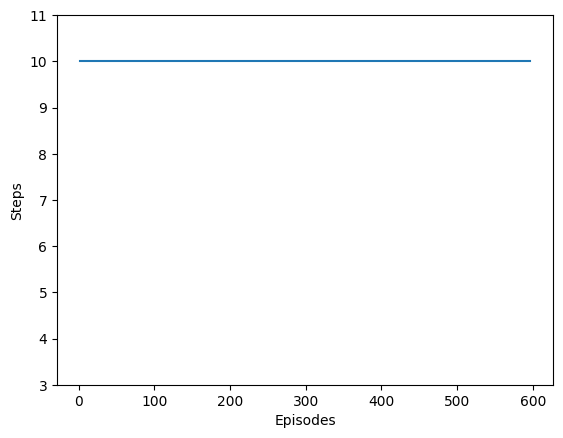

In [18]:
wins = sarsa.run(env, net, max_episode=1, max_steps=max_steps, catch_wins=True, plot_range=[3,11])

In [19]:
net(env.reset()[0])

tensor([-66.5541, -67.1200, -67.0294, -66.5540, -66.6658, -66.8097, -66.5492,
        -66.7773, -66.8372, -66.5884, -66.6016, -66.8245, -66.4114],
       grad_fn=<ViewBackward0>)